# **Convergence Speed and Noise Analysis**

This experiment focuses on:

1. Time (iterations) required to reach a target loss
2. Noise characteristics in SGD updates

We quantify differences rather than just visualizing them.

In [9]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.model import LogisticRegression
from src.optimizers.batch_gd import BatchGradientDescent
from src.optimizers.stochastic_gd import StochasticGradientDescent
from src.optimizers.minibatch_gd import MiniBatchGradientDescent

from src.utils.data import generate_dataset, standardize
from src.utils.seed import set_seed

In [11]:
set_seed(42)

X, y = generate_dataset()
X = standardize(X)

## **Defining Convergence**

We define convergence as reaching a target loss threshold.

This allows comparison across optimizers in a measurable way.

In [12]:
def iterations_to_threshold(losses, threshold):
    for i, l in enumerate(losses):
        if l <= threshold:
            return i
    return len(losses)

In [13]:
threshold = 0.3
records = []

# Batch GD
set_seed(42)
model = LogisticRegression(X.shape[1])
opt = BatchGradientDescent(lr=0.01, epochs=50)
loss = opt.train(model, X, y)

records.append(("Batch GD", iterations_to_threshold(loss, threshold)))


# SGD
set_seed(42)
model = LogisticRegression(X.shape[1])
opt = StochasticGradientDescent(lr=0.01, epochs=5)
loss = opt.train(model, X, y)

records.append(("SGD", iterations_to_threshold(loss, threshold)))


# Mini-batch
for bs in [16, 32, 64]:
    set_seed(42)
    model = LogisticRegression(X.shape[1])
    opt = MiniBatchGradientDescent(lr=0.01, epochs=20, batch_size=bs)

    loss = opt.train(model, X, y)
    records.append((f"MiniBatch ({bs})", iterations_to_threshold(loss, threshold)))

In [14]:
df = pd.DataFrame(records, columns=["Method", "Iterations_to_Threshold"])

from src.utils.logger import log_experiment

for method, iters in records:
    log_experiment(
        "../logs/experiment_log.csv",
        config={
            "method": method,
            "lr": 0.01,
            "dataset": "synthetic_500x20",
        },
        results={
            "iterations_to_threshold": iters
        }
    )

from src.utils.io import ensure_dir

ensure_dir("../outputs")

df.to_csv("../outputs/metrics.csv", index=False)

df

,Method,Iterations_to_Threshold
0,Batch GD,50
1,SGD,1666
2,MiniBatch (16),333
3,MiniBatch (32),320
4,MiniBatch (64),160


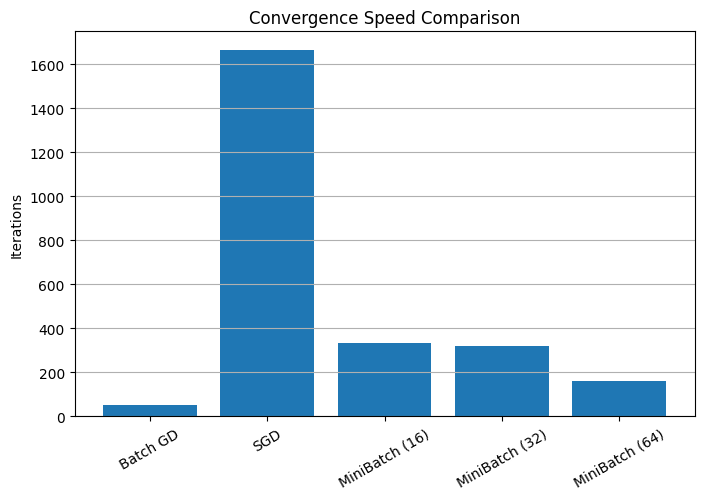

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(df["Method"], df["Iterations_to_Threshold"])
plt.xticks(rotation=30)

plt.ylabel("Iterations")
plt.title("Convergence Speed Comparison")
plt.grid(axis="y")

from src.utils.io import ensure_dir

ensure_dir("../experiments")

plt.savefig(
    "../experiments/convergence_speed.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

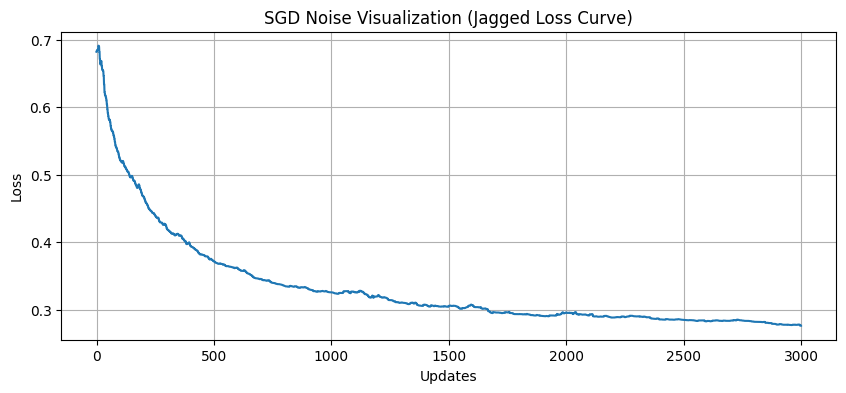

In [16]:
set_seed(42)

model = LogisticRegression(X.shape[1])
opt = StochasticGradientDescent(lr=0.01, epochs=3)

loss = opt.train(model, X, y)

plt.figure(figsize=(10, 4))
plt.plot(loss)

plt.title("SGD Noise Visualization (Jagged Loss Curve)")
plt.xlabel("Updates")
plt.ylabel("Loss")
plt.grid()

ensure_dir("../experiments")

plt.savefig(
    "../experiments/noise_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Key Takeaways**

- SGD reaches regions quickly but oscillates
- Batch GD converges smoothly but slowly
- Mini-batch provides the best practical trade-off

## **Important Observation**

Even for convex problems:

Optimization path != trivial

Choice of optimizer significantly impacts:
- Training stability
- Speed
- Practical usability

## **Final Conclusions**

This study compared Batch Gradient Descent, Stochastic Gradient Descent (SGD), and Mini-batch Gradient Descent on a controlled logistic regression problem.

### **Key Observations**

- **Batch Gradient Descent**
  - Achieved the fastest convergence to the defined threshold
  - Exhibited stable and smooth loss reduction
  - Benefited from low-variance gradient estimates

- **Stochastic Gradient Descent (SGD)**
  - Showed highly noisy updates with significant variance
  - Required more iterations to reliably reach the threshold
  - Demonstrated sensitivity to learning rate

- **Mini-batch Gradient Descent**
  - Provided a balance between stability and computational efficiency
  - However, did not outperform Batch GD in this controlled setup
  - Performance varied with batch size, indicating sensitivity to configuration

### **Important Insight**

Contrary to common expectations, Batch Gradient Descent converged faster than stochastic methods in this experiment. This highlights that:

- The efficiency of SGD is highly dependent on hyperparameter tuning
- Noise in SGD can delay convergence to strict thresholds
- For well-conditioned convex problems, stable gradients may outperform stochastic updates

### **Takeaway**

Optimization strategy is not universally optimal — it depends on:
- Problem structure
- Learning rate
- Desired convergence criteria

Understanding these trade-offs is critical in real-world machine learning systems.